In [1]:
import numpy as np
import sys 
import sys
sys.path.append('../scripts')
import assembly_tree as at
sys.path.append('../scripts')
import mcmc 
import networkx as nx 
import matplotlib.pyplot as plt 
import numpy as np 
import json
import os
import treelib
import importlib
import copy
#import pandas as pd
from tqdm.notebook import tqdm  # Use tqdm for Jupyter Notebook

importlib.reload(at)

<module 'assembly_tree' from '/Users/glover.co/Documents/laszlo/NetDesign/notebooks/../scripts/assembly_tree.py'>

In [2]:
def encode_tree(node,Tree):
    # Base case: if the node is a leaf, return just the count
    if not node.is_leaf(Tree) or len(Tree.children(node.identifier)) == 0:
        return [len(node.data.nodes)]
    
    # Otherwise, encode the subtree for each child
    encoded_children = [encode_tree(child,Tree) for child in sorted(Tree.children(node.identifier),key = lambda v: (-Tree.depth(v),-len(v.data.nodes)))]
    
    return [len(node.data.nodes)] + [encoded_children]

In [3]:
def encode_tree(node,AssemblyTree,count=True):
    if count:
        # Base case: if the node is a leaf, return just the count
        if not node.is_leaf(AssemblyTree.Tree) or len(AssemblyTree.Tree.children(node.identifier)) == 0:
            return [len(node.data.nodes)]
        
        # Otherwise, encode the subtree for each child
        encoded_children = [encode_tree(child,AssemblyTree) for child in sorted(AssemblyTree.Tree.children(node.identifier),key = lambda v: (-AssemblyTree.Tree.depth(v),-len(v.data.nodes)))]
        
        return [len(node.data.nodes)] + [encoded_children]
    else:
        # Base case: if the node is a leaf, return just the count
        if not node.is_leaf(AssemblyTree.Tree) or len(AssemblyTree.Tree.children(node.identifier)) == 0:
            # return [sorted(node.data.nodes)]
            return [list(AssemblyTree.X[sorted(node.data.nodes),:].sum(axis=0))]
        
        # Otherwise, encode the subtree for each child
        encoded_children = [encode_tree(child,AssemblyTree,count=False) for child in sorted(AssemblyTree.Tree.children(node.identifier),key = lambda v: (-AssemblyTree.Tree.depth(v),-len(v.data.nodes),min(v.data.nodes)))]
        
        # return [sorted(node.data.nodes)] + [encoded_children]
        # print(AssemblyTree.X[sorted(node.data.nodes),:])
        return [list(AssemblyTree.X[sorted(node.data.nodes),:].sum(axis=0))] + [encoded_children]

In [2]:
protein_human_path = '/Users/glover.co/Documents/laszlo/NetDesign/data/proteins/human'
circuit_path = '/Users/glover.co/Documents/laszlo/NetDesign/data/circuits/ltspice_demos'


In [3]:
target = nx.read_edgelist(f'{circuit_path}/edgefiles/LTC6268_isoSPI_DiffAmp.edge', nodetype=int)
X = np.loadtxt(f'{circuit_path}/Xfiles/X_LTC6268_isoSPI_DiffAmp.txt')
O = at.extract_O(target, X)
capacity = at.extract_deg_cap(target, X).reshape(-1)

In [12]:
initial_graph = nx.Graph()
initial_graph.add_nodes_from(np.arange(X.shape[0]))
at.prob_dist(X, O, capacity, max_iters=2, max_edges=True, initial_graph=initial_graph, rewire_est=True)

start milp
True


KeyboardInterrupt: 

In [34]:
graphs_rw = [target.copy()]
counts_rw = [1]
for i in tqdm(range(1000)):
    p = at.rewire(target,X,O,capacity,1000,sample=False)
    for g in graphs_rw:
        if nx.is_isomorphic(g, p):
            counts_rw[graphs_rw.index(g)] += 1
            break
    else:
        graphs_rw.append(p.copy())
        counts_rw.append(1)

  0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 

([<matplotlib.lines.Line2D at 0x12f252d50>], 841)

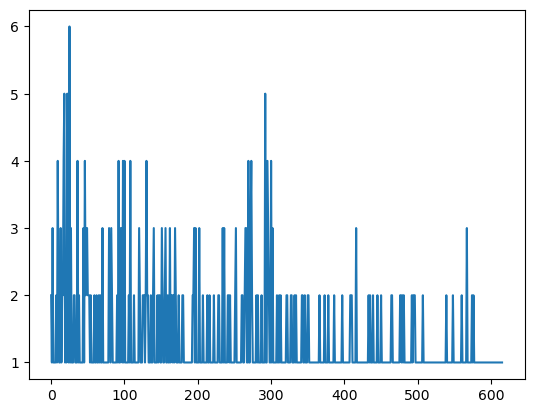

In [35]:
plt.plot(counts_rw), sum(counts_rw)

In [7]:
ex0 = mcmc.DesignMCMC(initial_tree)
Tis = np.ones(100)
ex0.run_mcmc(100,Tis)

Text(0.5, 1.0, '[np.float64(1.0)]')

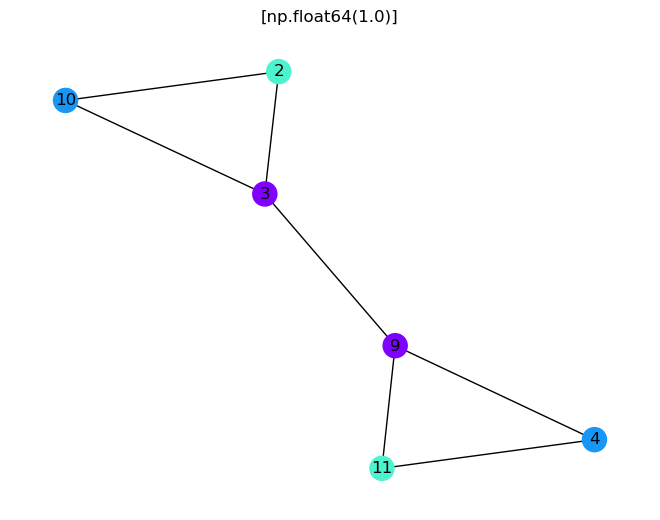

In [8]:
at.draw_network(ex0.cur_T.Tree.get_node(0).data.subgraph[0],X,with_labels=True)
plt.title(ex0.cur_T.Tree.get_node(0).data.p)

In [9]:
ex0.cur_T.Tree.show()

0
├── 1
│   ├── 6
│   └── 7
├── 2
├── 3
└── 4



In [16]:
ex0.cur_T.Tree.get_node(0).data.p


[0, np.float64(0.511)]

In [12]:
ex0.cur_T.known_p

{((2.0, 2.0, 2.0, 0.0, 0.0, 0.0),): [0, np.float64(0.511)],
 ((0.0, 1.0, 1.0, 0.0, 0.0, 0.0),): [np.float64(1.0)],
 ((0.0, 0.0, 1.0, 0.0, 0.0, 0.0),): [np.float64(1.0)],
 ((1.0, 1.0, 0.0, 0.0, 0.0, 0.0),): [np.float64(1.0)],
 ((1.0, 0.0, 0.0, 0.0, 0.0, 0.0),): [np.float64(1.0)],
 ((0.0, 1.0, 2.0, 0.0, 0.0, 0.0),
  (((0.0, 1.0, 1.0, 0.0, 0.0, 0.0),),
   ((0.0, 0.0, 1.0, 0.0, 0.0, 0.0),))): [np.float64(1.0)],
 ((2.0, 1.0, 0.0, 0.0, 0.0, 0.0),
  (((1.0, 1.0, 0.0, 0.0, 0.0, 0.0),),
   ((1.0, 0.0, 0.0, 0.0, 0.0, 0.0),))): [np.float64(1.0)],
 ((2.0, 2.0, 2.0, 0.0, 0.0, 0.0),
  (((0.0, 1.0, 2.0, 0.0, 0.0, 0.0),
    (((0.0, 1.0, 1.0, 0.0, 0.0, 0.0),), ((0.0, 0.0, 1.0, 0.0, 0.0, 0.0),))),
   ((2.0, 1.0, 0.0, 0.0, 0.0, 0.0),
    (((1.0, 1.0, 0.0, 0.0, 0.0, 0.0),),
     ((1.0, 0.0, 0.0, 0.0, 0.0, 0.0),))))): [0, np.float64(0.44)],
 ((2.0, 2.0, 2.0, 0.0, 0.0, 0.0),
  (((2.0, 1.0, 0.0, 0.0, 0.0, 0.0),
    (((1.0, 1.0, 0.0, 0.0, 0.0, 0.0),), ((1.0, 0.0, 0.0, 0.0, 0.0, 0.0),))),
   ((0.0, 1.0, 1.0, 0

In [25]:
ex0.cur_T.update_tree(dist=[.25,.25,0,0,.25,.25])

In [8]:
ex0.cur_T.update_prob(5)

Node id 5


AttributeError: 'NoneType' object has no attribute 'data'

In [ ]:
tuple(np.array([2,2,2]))

In [ ]:
node = initial_tree.Tree.get_node(0)
node.is_leaf(initial_tree.Tree)

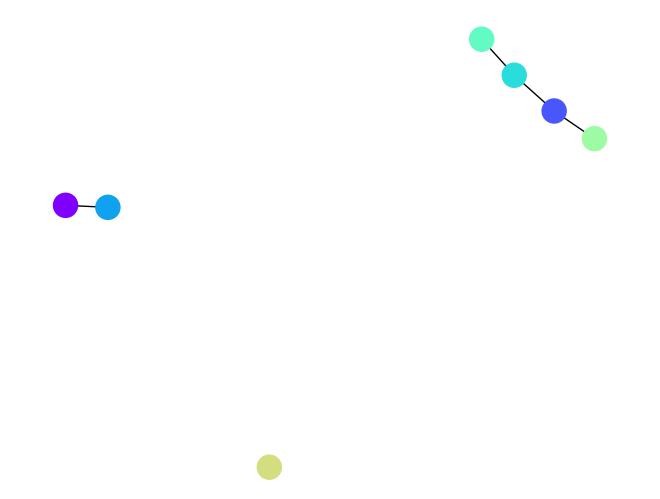

In [5]:
g = nx.fast_gnp_random_graph(7,.3)
X = np.eye(10)
O = at.extract_O(g, X)
capacity = at.extract_deg_cap(g, X).reshape(-1)
at.draw_network(g,X)

In [6]:
initial_tree = mcmc.AssemblyTree(g,X,O,capacity)
Tis = np.ones(10000)
c1q = mcmc.DesignMCMC(initial_tree)


In [7]:
initial_tree.known_p

AttributeError: 'AssemblyTree' object has no attribute 'known_p'

In [8]:
tree_list = [encode_tree(initial_tree.Tree.get_node(0),copy.deepcopy(initial_tree),count=True)]
uniq_tree_list = [encode_tree(initial_tree.Tree.get_node(0),copy.deepcopy(initial_tree),count=True)]
uniq_assembly_trees = [copy.deepcopy(initial_tree)]
assembly_trees = [copy.deepcopy(initial_tree)]
num_uniq_tree = np.zeros(10000)
walk_network = nx.Graph()
walk_network.add_node(0)  # Add the initial tree as the first node in the network
last_node = 0

for i in range(10000):
    if i % 100 == 0:
        print(f"Iteration {i}")
    c1q.run_mcmc(1,[1],dist=[.25,.25,0,0,.25,.25],prior='uniform')
    assembly_trees.append(copy.deepcopy(c1q.cur_T))
    tree_list.append(encode_tree(c1q.cur_T.Tree.get_node(0),copy.deepcopy(c1q.cur_T),count=True))
    found = False
    for j, tree in enumerate(uniq_tree_list):
        if tree == encode_tree(c1q.cur_T.Tree.get_node(0),c1q.cur_T,count=True):
            walk_network.add_edge(last_node,j)
            found= True
            last_node = j
            num_uniq_tree[i] = len(uniq_tree_list)
            break
    if not found:
        uniq_tree_list.append(encode_tree(c1q.cur_T.Tree.get_node(0),copy.deepcopy(c1q.cur_T),count=True))
        uniq_assembly_trees.append(copy.deepcopy(c1q.cur_T))
        walk_network.add_node(len(uniq_tree_list)-1)
        walk_network.add_edge(len(uniq_tree_list)-2,len(uniq_tree_list)-1)
        last_node = len(uniq_tree_list)-1
        num_uniq_tree[i] = len(uniq_tree_list)

Iteration 0
Iteration 100
Iteration 200
Iteration 300
Iteration 400
Iteration 500
Iteration 600
Iteration 700
Iteration 800
Iteration 900
Iteration 1000
Iteration 1100
Iteration 1200
Iteration 1300
Iteration 1400
Iteration 1500
Iteration 1600
Iteration 1700
Iteration 1800
Iteration 1900
Iteration 2000
Iteration 2100
Iteration 2200
Iteration 2300
Iteration 2400
Iteration 2500
Iteration 2600
Iteration 2700
Iteration 2800
Iteration 2900
Iteration 3000
Iteration 3100
Iteration 3200
Iteration 3300
Iteration 3400
Iteration 3500
Iteration 3600
Iteration 3700
Iteration 3800
Iteration 3900
Iteration 4000
Iteration 4100
Iteration 4200
Iteration 4300
Iteration 4400
Iteration 4500
Iteration 4600
Iteration 4700
Iteration 4800
Iteration 4900
Iteration 5000
Iteration 5100
Iteration 5200
Iteration 5300
Iteration 5400
Iteration 5500
Iteration 5600
Iteration 5700
Iteration 5800
Iteration 5900
Iteration 6000
Iteration 6100
Iteration 6200
Iteration 6300
Iteration 6400
Iteration 6500
Iteration 6600
Iterati

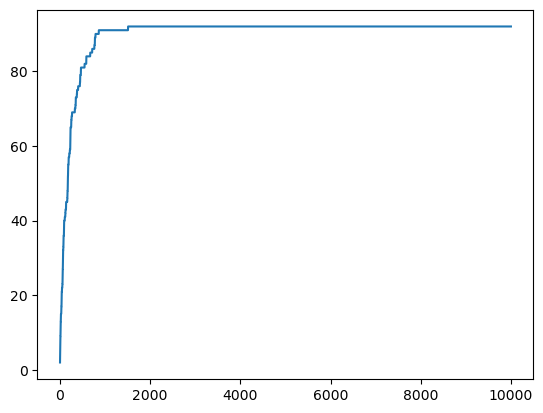

In [9]:
plt.plot(np.arange(len(num_uniq_tree)), num_uniq_tree)

In [15]:
loops = nx.selfloop_edges(walk_network)
walk_network.remove_edges_from(loops)
pos = nx.kamada_kawai_layout(walk_network, scale=2)


In [ ]:
nx.draw(walk_network, with_labels=True, pos = pos, node_size=10, font_size=12)

In [ ]:
[walk_network.degree(i) for i in nx.shortest_path(walk_network, source=0, target=966)]

In [ ]:
initial_tree.update_tree(dist=[.25,.25,0,0,.25,.25])

In [ ]:
initial_tree.known_p

In [ ]:
def convert_to_tuple(data):
    if isinstance(data, list):
        return tuple(convert_to_tuple(item) for item in data)
    return data

In [ ]:
convert_to_tuple([1, [1, 1, [1, [1, [1]]]]])

In [ ]:
uniq_tree_list

In [ ]:
import random
count = uniq_assembly_trees[2].Tree.get_node(5).data.count
n_children = random.randint(2, count-1)

In [ ]:
mcmc.get_integer_partition(count,n_children)

In [26]:

depths = []
uniq_depths = []
for tree in assembly_trees:
    depths.append(tree.Tree.depth())
for tree in uniq_assembly_trees:
    uniq_depths.append(tree.Tree.depth())

In [27]:
x_depths = np.unique(depths)
x_uniq_depths = np.unique(uniq_depths)
depths = np.unique_counts(depths).counts / np.sum(np.unique_counts(depths).counts)
uniq_depths = np.unique_counts(uniq_depths).counts / np.sum(np.unique_counts(uniq_depths).counts)

In [ ]:
x_depths

In [ ]:
plt.bar(x_depths,depths,label='All',alpha=0.5)
plt.bar(x_uniq_depths,uniq_depths,label='Unique',alpha=0.5)
plt.xlabel('Depth of Tree')
plt.ylabel('Frequency')
plt.title('Depth Distribution of Trees with Current MCMC (Node Content)')
plt.legend()
plt.show()

In [13]:
c1q.cur_T.split(0)

In [16]:
c1q.cur_T.add_branching_point(0)

In [21]:
c1q.cur_T.add_branching_point(0)

In [ ]:
c1q.cur_T.Tree.children(18)

In [23]:
nodes = c1q.cur_T.Tree.nodes    

In [36]:
def compare_trees(tree1, tree2):
    tree1_dict = {}
    tree2_dict = {}
    depth1 = tree1.Tree.depth()
    depth2 = tree2.Tree.depth()
    if depth1 != depth2:
        return False
    next_children1 = []
    cur_level1 = [tree1.Tree.root]
    next_children2 = []
    cur_level2 = [tree2.Tree.root]
    for i in range(depth1):
        tree1_dict[i] = cur_level1
        tree2_dict[i] = cur_level2
        # Get number of children for each node at depth
        for j in range(len(cur_level1)):
            children1 = cur_level1[j][1]
            children2 = cur_level2[j][1]
            if len(children1) != len(children2):
                return False
            # Sort children by number of children
            children1.sort(key=lambda x: len(tree1.Tree.get_node(x).data.nodes))
            children2.sort(key=lambda x: len(tree2.Tree.get_node(x).data.nodes))
            next_children1.extend([(tree1.Tree.get_node(children1[k]), tree1.Tree.get_node(children1[k]).data.nodes) for k in range(len(children1))])
            next_children2.extend([(tree2.Tree.get_node(children2[k]), tree2.Tree.get_node(children2[k]).data.nodes) for k in range(len(children2))])
        cur_level1 = next_children1
        cur_level2 = next_children2
        next_children1 = []
        next_children2 = []
    return True

In [ ]:
c1q.cur_T.Tree.show()

In [38]:
c1q2 = copy.deepcopy(c1q)

In [ ]:
compare_trees(c1q.cur_T, c1q2.cur_T)

In [80]:
def encode_tree(node,Tree):
    # Base case: if the node is a leaf, return just the count
    if not node.is_leaf(Tree) or len(Tree.children(node.identifier)) == 0:
        return [len(node.data.nodes)]
    
    # Otherwise, encode the subtree for each child
    encoded_children = [encode_tree(child,Tree) for child in sorted(Tree.children(node.identifier),key = lambda v: (-Tree.depth(v),-len(v.data.nodes)))]
    
    return [len(node.data.nodes)] + [encoded_children]



In [ ]:
encode_tree(initial_tree.Tree.get_node(0),initial_tree.Tree)

In [47]:
initial_tree = mcmc.AssemblyTree(target,X,O,capacity)

In [62]:
initial_tree.update_tree(dist=[.25,.25,0,0,.25,.25])

In [ ]:
initial_tree.Tree.show()

In [ ]:
initial_tree.Tree.get_node(0).data.nodes

In [ ]:
sorted(initial_tree.Tree.children(0),key= lambda v: (-initial_tree.Tree.depth(v),-len(initial_tree.Tree.get_node(v).data.nodes)))

In [70]:
children = initial_tree.Tree.children(0)

In [72]:
v =children[0]

In [ ]:
initial_tree.Tree.depth(v)

In [ ]:
v.data.nodes

In [75]:
initial_tree.Tree.get_node(v)

In [ ]:
v